# SHL Hiring Assessment 2026 — Grammar Scoring Engine (v12, final candidate)

**Task:** predict a continuous MOS grammar score (0–5) from a 45–60 s speech clip (769 train / 216 test clips).
**Metrics:** RMSE and Pearson correlation.

## Approach in brief
Grammar ratings depend on *what is said* and *how it is delivered*. Over the development history (section 10) one result was consistent: **audio representations carry most of the signal**, the **fine-tuned transformer on the transcript is the most valuable complementary model**, and everything else (more handcrafted features, pruning, hyper-parameter tuning, blending near-identical models) moved the score by less than the noise level.

The pipeline is a single, fully reproducible stack:
1. **Audio views:** temporal mean + std pooling of WavLM-base, WavLM-large and Whisper-small-encoder hidden layers → Ridge / SVR heads.
2. **Transcript view:** Whisper-small transcript → handcrafted + GPT-2 perplexity + LanguageTool + spaCy features (V10-B engineered set), MPNet embeddings, and a fine-tuned DeBERTa-v3 regressor.
3. **Multimodal Ridge** over features + audio + text, with fold-safe preprocessing.
4. **Stacker:** non-negative linear regression over out-of-fold (OOF) predictions (blend + calibration), no further calibration.

## What is new in v12
1. **Clean-up:** the 10 % blend with a frozen `submission_8.csv` is **removed** (it gained ≈ 0.0001 on the leaderboard, could not be validated by CV and depended on a file this notebook does not generate). The notebook now depends only on the competition data and public pretrained models.
2. **One controlled experiment on the strongest lever:** in earlier ablations, dropping the fine-tuned DeBERTa hurt the stack more than dropping any audio view. v12 therefore strengthens that branch: **DeBERTa averaged over 3 seeds** and an additional **ELECTRA-base** regressor (a discriminator pre-trained to detect replaced tokens, i.e. sensitive to ungrammatical wording), 3 seeds.
3. **Pre-registered decision rule:** the new fine-tuned models are adopted *only if* the repeated-CV stack RMSE improves by **≥ 0.002** over the control (V10-B) without losing Pearson; otherwise the control is submitted. The rule is fixed before the results are seen, so the choice among four variants cannot be tuned to noise.

**Setup:** Kaggle GPU (T4), Internet on, competition data attached. To skip the slow steps, attach the cached files of earlier runs as an input dataset (names unchanged): `transcripts_whisper_native_v3.csv`, `emb_wavlm_v3_meanstd.npy`, `emb_whisper_enc_v4.npy`, `emb_wavlm_large_v4.npy`, `ft_preds_<fingerprint>.npz`. The new fine-tuning runs cache per-seed predictions (`ft_*_seed*_<fingerprint>.npz`).

## 1. Setup and data discovery

In [1]:
import os, re, math, time, zlib, hashlib, warnings, subprocess, sys
from collections import defaultdict
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import Markdown, display
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")

# ---- switches (set to False to skip heavy parts) ----
USE_WAVLM_BASE  = True   # ~10 min on a T4 (cached after first run)
USE_WHISPER_ENC = True   # ~5-8 min (estimate)
USE_WAVLM_LARGE = True   # ~20-30 min (estimate); set False for a faster run
USE_FINETUNE    = True   # DeBERTa seed 0, 5 folds, ~6 min (cached)
USE_EXTRA_FT    = True   # v12 experiment: DeBERTa seeds 1-2 + ELECTRA seeds 0-2 (~20-25 min on a T4, estimate)
WORK = "/kaggle/working"

import torch, librosa
GPU = torch.cuda.is_available()
DEVICE = 0 if GPU else -1
dev_str = "cuda" if GPU else "cpu"
print("GPU available:", GPU)
SR = 16000

GPU available: True


In [2]:
# ---- Locate competition files. Train and test folders contain files with the SAME names, so keep them per-folder. ----
ROOT = "/kaggle/input"
csv_paths, by_dir, input_files = {}, defaultdict(dict), {}
for dirpath, _, files in os.walk(ROOT):
    for f in files:
        full = os.path.join(dirpath, f)
        if f in ("train.csv", "test.csv", "sample_submission.csv"):
            csv_paths[f] = full
        elif f.lower().endswith(".wav"):
            by_dir[dirpath][f] = full
        else:
            input_files[f] = full          # candidate caches from attached previous runs
for d, m in by_dir.items():
    print(len(m), "wav |", d)

train = pd.read_csv(csv_paths["train.csv"])
test = pd.read_csv(csv_paths["test.csv"])

def best_dir(names, exclude=None):
    names = set(names)
    cands = [d for d in by_dir if d != exclude]
    return max(cands, key=lambda d: (len(names & set(by_dir[d])), -abs(len(by_dir[d]) - len(names))))

train_dir = best_dir(train.filename)
test_dir = best_dir(test.filename, exclude=train_dir)
print("train audio dir:", train_dir); print("test audio dir :", test_dir)
train["path"] = train.filename.map(by_dir[train_dir])
test["path"] = test.filename.map(by_dir[test_dir])
assert train.path.notna().all() and test.path.notna().all(), "audio files missing"

all_df = pd.concat([train.assign(split="train"), test.assign(split="test")], ignore_index=True)
tr_mask = (all_df.split == "train").values
te_mask = ~tr_mask
y = all_df.loc[tr_mask, "label"].values.astype(float)
print(all_df.shape, "| train:", tr_mask.sum(), "| test:", te_mask.sum())

# ---- cache helpers: look in /kaggle/working first, then in attached inputs ----
def cache_path(name):
    p = os.path.join(WORK, name)
    return p if os.path.exists(p) else input_files.get(name)

def load_csv_cache(name, n=None):
    p = cache_path(name)
    if p is None: return None
    try:
        d = pd.read_csv(p)
        return d if (n is None or len(d) == n) else None
    except Exception:
        return None

def load_npy_cache(name, n=None):
    p = cache_path(name)
    if p is None: return None
    try:
        a = np.load(p)
        return a if (n is None or a.shape[0] == n) else None
    except Exception:
        return None

216 wav | /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test
769 wav | /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train
train audio dir: /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train
test audio dir : /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test
(985, 4) | train: 769 | test: 216


## 2. Label analysis

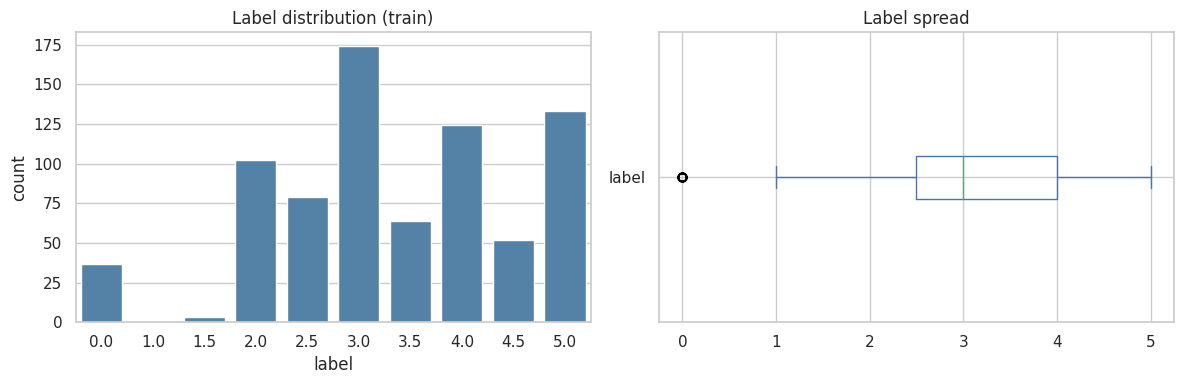

count    769.000
mean       3.313
std        1.239
min        0.000
25%        2.500
50%        3.000
75%        4.000
max        5.000
Name: label, dtype: float64
Baseline RMSE (predict the mean): 1.2382


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="label", data=train, ax=ax[0], color="steelblue"); ax[0].set_title("Label distribution (train)")
train["label"].plot.box(ax=ax[1], vert=False); ax[1].set_title("Label spread")
plt.tight_layout(); plt.show()
BASE_RMSE = float(np.sqrt(((y - y.mean())**2).mean()))
print(train["label"].describe().round(3)); print("Baseline RMSE (predict the mean):", round(BASE_RMSE, 4))

## 3. Transcription (Whisper, native long-form generation)
Whisper-small transcribes each 45–60 s clip with its native long-form `generate()` path. Transcripts are cached keyed by **(split, filename)** because train and test share file names. Fallback decoding uses sampling, so the random seed is fixed.

In [4]:
from transformers import AutoProcessor, WhisperForConditionalGeneration
TRANSCRIPT_CACHE = "transcripts_whisper_native_v3.csv"

def load_audio(path):
    y_, _ = librosa.load(path, sr=SR, mono=True)
    return y_

def transcribe_all(df, model_name="openai/whisper-small", batch_size=2):
    processor = AutoProcessor.from_pretrained(model_name)
    model = WhisperForConditionalGeneration.from_pretrained(
        model_name, dtype=torch.float16 if GPU else torch.float32, low_cpu_mem_usage=True).to(dev_str).eval()
    device = torch.device(dev_str)
    torch.manual_seed(SEED)
    out, paths = [], df["path"].tolist()
    for i in range(0, len(paths), batch_size):
        audios = [load_audio(p) for p in paths[i:i + batch_size]]
        inputs = processor(audios, sampling_rate=SR, return_tensors="pt", truncation=False,
                           padding="longest", return_attention_mask=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        if GPU: inputs["input_features"] = inputs["input_features"].to(dtype=torch.float16)
        with torch.inference_mode():
            ids = model.generate(**inputs, language="en", task="transcribe", return_timestamps=True,
                                 condition_on_prev_tokens=True, compression_ratio_threshold=1.35,
                                 logprob_threshold=-1.0, no_speech_threshold=0.6,
                                 temperature=(0.0, 0.2, 0.4, 0.6, 0.8, 1.0))
        out.extend(t.strip() for t in processor.batch_decode(ids, skip_special_tokens=True, clean_up_tokenization_spaces=False))
        if (i // batch_size) % 25 == 0: print(f"{min(i + batch_size, len(paths))}/{len(paths)}", end=" | ", flush=True)
    del model, processor
    if GPU: torch.cuda.empty_cache()
    return out

tr_cache = load_csv_cache(TRANSCRIPT_CACHE, len(all_df))
if tr_cache is not None and {"split", "filename", "transcript"}.issubset(tr_cache.columns):
    print("Using cached transcripts:", cache_path(TRANSCRIPT_CACHE))
    all_df = all_df.merge(tr_cache.fillna("")[["split", "filename", "transcript"]], on=["split", "filename"], how="left", validate="one_to_one")
    assert len(all_df) == tr_mask.size and all_df.transcript.notna().all(), "transcript merge failed"
else:
    t0 = time.time()
    all_df["transcript"] = transcribe_all(all_df)
    all_df[["split", "filename", "transcript"]].to_csv(os.path.join(WORK, TRANSCRIPT_CACHE), index=False)
    print(f"\nWhisper ASR done in {(time.time()-t0)/60:.1f} min")
all_df["transcript"] = all_df["transcript"].fillna("")
assert (all_df.split.values == np.where(tr_mask, "train", "test")).all()
TXT_HASH = hashlib.md5("\n".join(all_df.transcript).encode("utf-8")).hexdigest()[:8]   # keys all transcript-dependent caches
print("transcript fingerprint:", TXT_HASH)
all_df.sample(4, random_state=SEED)[["split", "filename", "label", "transcript"]]

Using cached transcripts: /kaggle/input/datasets/piyushshx/transcriptsv4/transcripts_whisper_native_v3.csv
transcript fingerprint: fe6bc6bc


,split,filename,label,transcript
613,train,audio_25.wav,3.0,we went to a resort last summer with my family...
451,train,audio_577.wav,4.0,So my favorite plus is nature. The best place ...
731,train,audio_86.wav,2.0,"Yeah, there was a scene in the crowded market ..."
436,train,audio_237.wav,3.0,The playground is composed of students who are...


## 4. Handcrafted features (V10-B engineered set)
The V4 feature set plus a focused set of grammar, syntax, sentence-complexity, repetition and error-density features. This is the feature set that gave the best CV in the V10 controlled comparison (V10-A baseline 0.4779, V10-B engineered **0.4761**, V10-C engineered + pruned 0.4770; later tests of additional construction/agreement/tense features did not improve CV and were rejected). Feature statistics below use training rows only and are diagnostics, never used for selection.

In [5]:
# ---- Existing V4/V9 handcrafted features ----
FILLERS = {"um", "uh", "er", "ah", "erm", "hmm", "mm", "like"}
SUBORD = {"because", "although", "though", "while", "whereas", "since", "unless", "if", "when", "which", "who", "whom",
          "whose", "that", "where", "however", "therefore", "moreover", "furthermore", "but", "so", "and", "or"}
AUX = {"is", "are", "was", "were", "be", "been", "being", "am", "have", "has", "had", "do", "does", "did",
       "will", "would", "can", "could", "should", "may", "might", "must"}

def split_sentences(text):
    s = [x.strip() for x in re.split(r"(?<=[.!?])\s+", text) if x.strip()]
    return s if s else ([text] if text.strip() else [])

def text_features(text):
    words = re.findall(r"[A-Za-z']+", text.lower()); n = len(words)
    sents = split_sentences(text)
    slen = np.array([len(re.findall(r"[A-Za-z']+", s)) for s in sents]) if sents else np.array([0])
    reps = sum(1 for a, b in zip(words, words[1:]) if a == b)
    tri = list(zip(words, words[1:], words[2:])); raw = text.encode("utf-8")
    run, best_run = 1, 1
    for a, b in zip(words, words[1:]):
        run = run + 1 if a == b else 1; best_run = max(best_run, run)
    return {
        "n_words": n, "n_unique": len(set(words)), "ttr": len(set(words)) / n if n else 0,
        "n_sents": len(sents), "avg_sent_len": slen.mean(), "std_sent_len": slen.std(), "max_sent_len": slen.max(),
        "short_sent_frac": (slen < 4).mean() if len(slen) else 1,
        "avg_word_len": np.mean([len(w) for w in words]) if n else 0,
        "long_word_frac": np.mean([len(w) >= 7 for w in words]) if n else 0,
        "filler_rate": sum(w in FILLERS for w in words) / n if n else 0,
        "repeat_rate": reps / n if n else 0, "max_word_run": best_run,
        "subord_rate": sum(w in SUBORD for w in words) / n if n else 0,
        "aux_rate": sum(w in AUX for w in words) / n if n else 0,
        "comma_rate": text.count(",") / n if n else 0,
        "ends_with_punct": float(text.strip()[-1:] in ".!?") if text.strip() else 0,
        "lower_start_sents": np.mean([s[0].islower() for s in sents]) if sents else 0,
        "compress_ratio": len(raw) / max(len(zlib.compress(raw)), 1) if raw else 0,
        "trigram_repeat": 1 - len(set(tri)) / len(tri) if tri else 0,
    }

def audio_features(path):
    y_ = load_audio(path); dur = len(y_) / SR
    iv = librosa.effects.split(y_, top_db=30)
    speech = sum(e - s for s, e in iv) / SR
    return {"duration": dur, "speech_time": speech, "pause_ratio": 1 - speech / dur if dur else 0, "n_segments": len(iv)}

BASIC = load_csv_cache(f"feats_basic_{TXT_HASH}.csv", len(all_df))
if BASIC is None:
    t0 = time.time()
    TF = pd.DataFrame([text_features(t) for t in all_df.transcript])
    AF = pd.DataFrame([audio_features(p) for p in all_df.path])
    AF["wps"] = TF["n_words"] / AF["speech_time"].clip(lower=1)
    BASIC = pd.concat([TF, AF], axis=1); BASIC.to_csv(os.path.join(WORK, f"feats_basic_{TXT_HASH}.csv"), index=False)
    print(f"Basic features done in {time.time()-t0:.0f}s", BASIC.shape)
else:
    print("loaded cached basic features")

# ---- GPT-2 perplexity features ----
PF = load_csv_cache(f"feats_ppl_{TXT_HASH}.csv", len(all_df))
if PF is None:
    from transformers import AutoTokenizer, AutoModelForCausalLM
    gpt_tok = AutoTokenizer.from_pretrained("gpt2")
    gpt = AutoModelForCausalLM.from_pretrained("gpt2").to(dev_str).eval()

    @torch.no_grad()
    def sent_nll(sent):
        ids = gpt_tok(gpt_tok.bos_token + sent, return_tensors="pt", truncation=True, max_length=128).input_ids.to(gpt.device)
        if ids.shape[1] < 2: return np.nan
        return gpt(ids, labels=ids).loss.item()

    def ppl_features(text):
        nll = [x for x in (sent_nll(s) for s in split_sentences(text)) if not np.isnan(x)]
        if not nll: return {"nll_mean": np.nan, "nll_max": np.nan, "nll_std": np.nan, "nll_p75": np.nan}
        return {"nll_mean": np.mean(nll), "nll_max": np.max(nll), "nll_std": np.std(nll), "nll_p75": np.percentile(nll, 75)}

    t0 = time.time()
    PF = pd.DataFrame([ppl_features(t) for t in all_df.transcript])
    PF.to_csv(os.path.join(WORK, f"feats_ppl_{TXT_HASH}.csv"), index=False)
    print(f"Perplexity features done in {time.time()-t0:.0f}s")
    del gpt
    if GPU: torch.cuda.empty_cache()
else:
    print("loaded cached perplexity features")

# ---- LanguageTool grammar errors + spaCy syntax ----
from tqdm.auto import tqdm

LT_F = load_csv_cache(f"feats_lt_{TXT_HASH}.csv", len(all_df))
if LT_F is None:
    try:
        t0 = time.time()
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "language_tool_python"], check=True, timeout=300)
        import language_tool_python
        tool = language_tool_python.LanguageTool("en-US")
        def lt_feats(t):
            m = tool.check(t) if t.strip() else []
            n = max(len(t.split()), 1)
            rid = lambda x: str(getattr(x, "rule_id", getattr(x, "ruleId", "")))
            cat = lambda x: str(getattr(x, "category", ""))
            grammar = [x for x in m if cat(x) in ("GRAMMAR", "TYPOS", "PUNCTUATION") or "GRAMMAR" in rid(x)]
            return {"lt_errors": len(m), "lt_err_per_word": len(m) / n, "lt_grammar_err": len(grammar), "lt_grammar_per_word": len(grammar) / n}
        LT_F = pd.DataFrame([lt_feats(t) for t in tqdm(all_df.transcript, desc="LanguageTool")])
        tool.close()
        LT_F.to_csv(os.path.join(WORK, f"feats_lt_{TXT_HASH}.csv"), index=False)
        print(f"LanguageTool done in {time.time()-t0:.0f}s", LT_F.shape)
    except Exception as e:
        print("LanguageTool skipped:", repr(e)[:200]); LT_F = pd.DataFrame(index=all_df.index)
else:
    print("loaded cached LanguageTool features")

SP_F = load_csv_cache(f"feats_sp_{TXT_HASH}.csv", len(all_df))
if SP_F is None:
    try:
        t0 = time.time()
        import spacy
        try: nlp = spacy.load("en_core_web_sm")
        except OSError:
            subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], check=True, timeout=300)
            nlp = spacy.load("en_core_web_sm")
        def depth(tok):
            d = 0
            while tok.head.i != tok.i:
                tok = tok.head; d += 1
            return d
        def sp_feats(doc):
            sents = list(doc.sents); n = max(len(doc), 1)
            no_verb = np.mean([not any(tk.pos_ in ("VERB", "AUX") for tk in s) for s in sents]) if sents else 1
            no_subj = np.mean([not any(tk.dep_ in ("nsubj", "nsubjpass", "expl") for tk in s) for s in sents]) if sents else 1
            return {"sp_no_verb_sent": no_verb, "sp_no_subj_sent": no_subj,
                    "sp_clause_rate": sum(tk.dep_ in ("advcl", "ccomp", "relcl", "acl", "xcomp", "csubj") for tk in doc) / n,
                    "sp_max_depth": max([depth(tk) for tk in doc], default=0),
                    "sp_pos_variety": len({tk.pos_ for tk in doc}),
                    "sp_tense_variety": len({tk.morph.get("Tense")[0] for tk in doc if tk.morph.get("Tense")})}
        docs = nlp.pipe(all_df.transcript.tolist(), batch_size=32, disable=["ner", "lemmatizer"])
        SP_F = pd.DataFrame([sp_feats(d) for d in tqdm(docs, total=len(all_df), desc="spaCy")])
        SP_F.to_csv(os.path.join(WORK, f"feats_sp_{TXT_HASH}.csv"), index=False)
        print(f"spaCy done in {time.time()-t0:.0f}s", SP_F.shape)
    except Exception as e:
        print("spaCy skipped:", repr(e)[:200]); SP_F = pd.DataFrame(index=all_df.index)
else:
    print("loaded cached spaCy features")

FEATS = pd.concat([BASIC.reset_index(drop=True), PF.reset_index(drop=True), LT_F.reset_index(drop=True), SP_F.reset_index(drop=True)], axis=1)
FEATS = FEATS.replace([np.inf, -np.inf], np.nan)

# ============================================================
# V10: focused grammar / syntax / disfluency features
# ============================================================
V10_EXTRA_CACHE = f"feats_v10_extra_{TXT_HASH}.csv"
V10_EXTRA = load_csv_cache(V10_EXTRA_CACHE, len(all_df))

if V10_EXTRA is None:
    t0 = time.time()
    rows = []
    correction_markers = ("i mean", "what i mean", "actually", "sorry", "rather", "let me rephrase")

    def lexical_grammar_features(text):
        words = re.findall(r"[A-Za-z']+", text.lower())
        n = len(words)
        sents = split_sentences(text)
        slens = np.array([len(re.findall(r"[A-Za-z']+", s)) for s in sents], dtype=float) if sents else np.array([0.0])
        bigrams = list(zip(words, words[1:]))

        filler_sent_frac = (
            np.mean([any(w in FILLERS for w in re.findall(r"[A-Za-z']+", s.lower())) for s in sents])
            if sents else 0.0
        )
        repeat_bigram_rate = (
            (len(bigrams) - len(set(bigrams))) / max(len(bigrams), 1)
            if bigrams else 0.0
        )
        correction_count = sum(text.lower().count(m) for m in correction_markers)

        return {
            "v10_sent_len_cv": float(slens.std() / max(slens.mean(), 1.0)),
            "v10_sent_len_p90": float(np.percentile(slens, 90)),
            "v10_word_len_std": float(np.std([len(w) for w in words])) if words else 0.0,
            "v10_filler_sent_frac": float(filler_sent_frac),
            "v10_repeat_bigram_rate": float(repeat_bigram_rate),
            "v10_correction_marker_rate": float(correction_count / max(n, 1)),
            "v10_grammar_marker_rate": float(sum(w in {"although", "because", "whereas", "unless", "while"} for w in words) / max(n, 1)),
        }

    for t in tqdm(all_df.transcript.tolist(), desc="V10 lexical features"):
        rows.append(lexical_grammar_features(t))
    V10_EXTRA = pd.DataFrame(rows)
    V10_EXTRA.to_csv(os.path.join(WORK, V10_EXTRA_CACHE), index=False)
    print(f"V10 lexical features done in {time.time()-t0:.1f}s", V10_EXTRA.shape)

# More structured syntax features. This cache is separate so a rerun never has
# to rebuild the expensive Whisper/GPT-2/LanguageTool branches.
V10_SP_CACHE = f"feats_v10_spacy_{TXT_HASH}.csv"
V10_SP = load_csv_cache(V10_SP_CACHE, len(all_df))

if V10_SP is None:
    try:
        import spacy
        if "nlp" not in globals():
            try: nlp = spacy.load("en_core_web_sm")
            except OSError:
                subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], check=True, timeout=300)
                nlp = spacy.load("en_core_web_sm")

        def depth(tok):
            d = 0
            while tok.head.i != tok.i:
                tok = tok.head; d += 1
            return d

        def advanced_spacy_features(doc):
            toks = [t for t in doc if not t.is_space]
            alpha = [t for t in toks if t.is_alpha]
            n = max(len(alpha), 1)
            sents = list(doc.sents)

            dep_depths = np.array([depth(t) for t in toks], dtype=float) if toks else np.array([0.0])
            clauses = sum(t.dep_ in ("advcl", "ccomp", "relcl", "acl", "xcomp", "csubj") for t in toks)
            roots = sum(t.dep_ == "ROOT" for t in toks)
            frag = sum(
                (not any(t.pos_ in ("VERB", "AUX") for t in s))
                and (not any(t.dep_ in ("nsubj", "nsubjpass", "expl") for t in s))
                for s in sents
            )

            def pos_rate(pos):
                return sum(t.pos_ == pos for t in alpha) / n

            return {
                "v10_sp_avg_depth": float(dep_depths.mean()),
                "v10_sp_depth_p75": float(np.percentile(dep_depths, 75)),
                "v10_sp_depth_std": float(dep_depths.std()),
                "v10_sp_clause_per_sent": float(clauses / max(len(sents), 1)),
                "v10_sp_fragment_rate": float(frag / max(len(sents), 1)),
                "v10_sp_verb_rate": float((sum(t.pos_ in ("VERB", "AUX") for t in alpha)) / n),
                "v10_sp_noun_rate": float(pos_rate("NOUN")),
                "v10_sp_pronoun_rate": float(pos_rate("PRON")),
                "v10_sp_adj_rate": float(pos_rate("ADJ")),
                "v10_sp_adv_rate": float(pos_rate("ADV")),
                "v10_sp_prep_rate": float(pos_rate("ADP")),
                "v10_sp_conj_rate": float(pos_rate("CCONJ") + pos_rate("SCONJ")),
                "v10_sp_dep_variety": float(len({t.dep_ for t in toks})),
                "v10_sp_root_rate": float(roots / n),
            }

        docs = nlp.pipe(all_df.transcript.tolist(), batch_size=32, disable=["ner", "lemmatizer"])
        V10_SP = pd.DataFrame([advanced_spacy_features(d) for d in tqdm(docs, total=len(all_df), desc="V10 spaCy syntax")])
        V10_SP.to_csv(os.path.join(WORK, V10_SP_CACHE), index=False)
        print(f"V10 spaCy syntax done in {(time.time()-t0)/60:.1f} min", V10_SP.shape)
    except Exception as e:
        print("V10 spaCy syntax skipped:", repr(e)[:250])
        V10_SP = pd.DataFrame(index=all_df.index)

V10_EXTRA_FULL = pd.concat([V10_EXTRA.reset_index(drop=True), V10_SP.reset_index(drop=True)], axis=1)

# Derived error-density features use only already-computed LanguageTool counts.
if len(LT_F.columns):
    n_words = BASIC["n_words"].replace(0, np.nan)
    n_sents = BASIC["n_sents"].replace(0, np.nan)
    lt_plus = pd.DataFrame({
        "v10_lt_errors_per_sentence": LT_F["lt_errors"] / n_sents,
        "v10_lt_grammar_per_sentence": LT_F["lt_grammar_err"] / n_sents,
        "v10_lt_non_grammar_per_word": (LT_F["lt_errors"] - LT_F["lt_grammar_err"]) / n_words,
        "v10_lt_errors_per_100_words": 100.0 * LT_F["lt_errors"] / n_words,
        "v10_lt_grammar_per_100_words": 100.0 * LT_F["lt_grammar_err"] / n_words,
    })
    V10_EXTRA_FULL = pd.concat([V10_EXTRA_FULL.reset_index(drop=True), lt_plus.reset_index(drop=True)], axis=1)

V10_EXTRA_FULL = V10_EXTRA_FULL.replace([np.inf, -np.inf], np.nan)
FEATS_ENGINEERED = pd.concat([FEATS.reset_index(drop=True), V10_EXTRA_FULL.reset_index(drop=True)], axis=1)
print("Baseline handcrafted features :", FEATS.shape)
print("New V10 features              :", V10_EXTRA_FULL.shape)
print("Engineered feature matrix     :", FEATS_ENGINEERED.shape)

# Supervised diagnostics are for inspection only. They are never used globally
# to select features; fold-safe selection below recomputes correlations inside
# each training fold.
def train_target_corr_table(F):
    tmp = F.copy().astype(float)
    vals = {}
    for c in tmp.columns:
        x = tmp[c].copy()
        if x.isna().all() or x.nunique(dropna=True) <= 1:
            vals[c] = np.nan
            continue
        x = x.fillna(x.median())
        vals[c] = float(np.corrcoef(x.loc[tr_mask], y)[0,1])
    return pd.Series(vals).sort_values(key=lambda s: s.abs(), ascending=False)

print("\nTop V10 features by train-only Pearson correlation:")
display(train_target_corr_table(V10_EXTRA_FULL).head(15).to_frame("target_corr"))

def report_redundant_pairs(F, threshold=0.90):
    X = F.loc[tr_mask].astype(float).copy()
    X = X.loc[:, X.nunique(dropna=False) > 1]
    X = X.fillna(X.median())
    C = X.corr().abs()
    upper = C.where(np.triu(np.ones(C.shape), k=1).astype(bool))
    pairs = []
    for col in upper.columns:
        for row in upper.index:
            v = upper.loc[row, col]
            if pd.notna(v) and v >= threshold:
                pairs.append((row, col, float(v)))
    return pd.DataFrame(pairs, columns=["feature_1", "feature_2", "abs_corr"]).sort_values("abs_corr", ascending=False)

red_pairs = report_redundant_pairs(FEATS_ENGINEERED, threshold=0.90)
print(f"\nHighly correlated train-feature pairs (|r| >= 0.90): {len(red_pairs)}")
display(red_pairs.head(20))

loaded cached basic features
loaded cached perplexity features
loaded cached LanguageTool features
loaded cached spaCy features


V10 lexical features:   0%|          | 0/985 [00:00<?, ?it/s]

V10 lexical features done in 0.5s (985, 7)


V10 spaCy syntax:   0%|          | 0/985 [00:00<?, ?it/s]

V10 spaCy syntax done in 0.2 min (985, 14)
Baseline handcrafted features : (985, 39)
New V10 features              : (985, 26)
Engineered feature matrix     : (985, 65)

Top V10 features by train-only Pearson correlation:


,target_corr
v10_sp_dep_variety,0.345555
v10_repeat_bigram_rate,-0.233647
v10_word_len_std,0.221629
v10_lt_errors_per_100_words,-0.194809
v10_lt_grammar_per_100_words,-0.162022
v10_lt_non_grammar_per_word,-0.123602
v10_sp_adj_rate,0.121400
v10_sp_adv_rate,0.118283
v10_sent_len_cv,0.116419
v10_sp_depth_std,0.107790



Highly correlated train-feature pairs (|r| >= 0.90): 19


,feature_1,feature_2,abs_corr
17,lt_grammar_per_word,v10_lt_grammar_per_100_words,0.999437
13,lt_err_per_word,v10_lt_errors_per_100_words,0.999227
8,max_sent_len,v10_sent_len_p90,0.974249
11,v10_lt_errors_per_sentence,v10_lt_grammar_per_sentence,0.971324
7,avg_sent_len,v10_sent_len_p90,0.962799
9,v10_sp_avg_depth,v10_sp_depth_p75,0.954154
10,sp_max_depth,v10_sp_depth_std,0.947406
2,nll_mean,nll_p75,0.930038
6,lt_grammar_err,lt_grammar_per_word,0.927670
16,lt_grammar_err,v10_lt_grammar_per_100_words,0.927027


## 5. Embeddings

In [6]:
from sentence_transformers import SentenceTransformer
texts = all_df.transcript.tolist()
EMB_MPNET = SentenceTransformer("sentence-transformers/all-mpnet-base-v2", device=dev_str).encode(
    texts, batch_size=32, normalize_embeddings=True, show_progress_bar=False)
print("Text embeddings:", EMB_MPNET.shape)
if GPU: torch.cuda.empty_cache()

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Text embeddings: (985, 768)


In [7]:
from transformers import AutoFeatureExtractor, AutoModel

def extract_ssl(model_name, layers, cache_name, desc):
    # mean+std pooled hidden states of a self-supervised speech model (WavLM family)
    cached = load_npy_cache(cache_name, len(all_df))
    if cached is not None:
        print(f"loaded cached {desc}:", cached.shape); return cached
    try:
        fe = AutoFeatureExtractor.from_pretrained(model_name)
        model = AutoModel.from_pretrained(model_name).to(dev_str).eval()
        rows, t0 = [], time.time()
        with torch.inference_mode():
            for p in tqdm(all_df.path, desc=desc):
                wav = load_audio(p)[: SR * 70]
                inp = fe(wav, sampling_rate=SR, return_tensors="pt").input_values.to(dev_str)
                if GPU:
                    with torch.autocast("cuda", dtype=torch.float16):
                        hs = model(inp, output_hidden_states=True).hidden_states
                else:
                    hs = model(inp, output_hidden_states=True).hidden_states
                pooled = []
                for l in layers:
                    h = hs[l].float().squeeze(0)
                    pooled += [h.mean(0), h.std(0, unbiased=False)]
                rows.append(torch.cat(pooled).cpu().numpy())
        E = np.stack(rows).astype(np.float32); np.save(os.path.join(WORK, cache_name), E)
        print(f"{desc} done in {(time.time()-t0)/60:.1f} min", E.shape)
        del model, fe
        if GPU: torch.cuda.empty_cache()
        return E
    except Exception as e:
        print(f"{desc} skipped:", repr(e)[:300]); return None

EMB_WAVLM_BASE = extract_ssl("microsoft/wavlm-base-plus", (4, 8, 12), "emb_wavlm_v3_meanstd.npy", "WavLM-base") if USE_WAVLM_BASE else None

loaded cached WavLM-base: (985, 4608)


In [8]:
def extract_whisper_encoder(cache_name="emb_whisper_enc_v4.npy", layers=(6, 9, 12)):
    cached = load_npy_cache(cache_name, len(all_df))
    if cached is not None:
        print("loaded cached Whisper-encoder embeddings:", cached.shape); return cached
    try:
        from transformers import WhisperFeatureExtractor, WhisperModel
        wfe = WhisperFeatureExtractor.from_pretrained("openai/whisper-small")
        enc = WhisperModel.from_pretrained("openai/whisper-small").encoder.to(dev_str).eval()
        CH, rows, t0 = SR * 30, [], time.time()
        with torch.inference_mode():
            for p in tqdm(all_df.path, desc="Whisper encoder"):
                wav = load_audio(p)
                chunks = [wav[i:i + CH] for i in range(0, len(wav), CH)]
                chunks = [c for c in chunks if len(c) >= SR] or [wav]            # drop a <1 s tail
                feats = wfe(chunks, sampling_rate=SR, return_tensors="pt").input_features.to(dev_str)
                if GPU:
                    with torch.autocast("cuda", dtype=torch.float16):
                        hs = enc(feats, output_hidden_states=True).hidden_states
                else:
                    hs = enc(feats, output_hidden_states=True).hidden_states
                valid = [max(1, min(1500, math.ceil(len(c) / 320))) for c in chunks]   # 50 encoder frames per second
                pooled = []
                for l in layers:
                    h = torch.cat([hs[l][j, :v].float() for j, v in enumerate(valid)], dim=0)   # valid frames only
                    pooled += [h.mean(0), h.std(0, unbiased=False)]
                rows.append(torch.cat(pooled).cpu().numpy())
        E = np.stack(rows).astype(np.float32); np.save(os.path.join(WORK, cache_name), E)
        print(f"Whisper-encoder embeddings done in {(time.time()-t0)/60:.1f} min", E.shape)
        del enc, wfe
        if GPU: torch.cuda.empty_cache()
        return E
    except Exception as e:
        print("Whisper-encoder embeddings skipped:", repr(e)[:300]); return None

EMB_WHISPER_ENC = extract_whisper_encoder() if USE_WHISPER_ENC else None

loaded cached Whisper-encoder embeddings: (985, 4608)


In [9]:
EMB_WAVLM_LARGE = extract_ssl("microsoft/wavlm-large", (8, 16, 24), "emb_wavlm_large_v4.npy", "WavLM-large") if USE_WAVLM_LARGE else None

AUDIO_VIEWS = {k: v for k, v in {"wavlm_base": EMB_WAVLM_BASE, "whisper_enc": EMB_WHISPER_ENC, "wavlm_large": EMB_WAVLM_LARGE}.items() if v is not None}
print("Audio views available:", {k: v.shape for k, v in AUDIO_VIEWS.items()})
assert AUDIO_VIEWS, "no audio view could be computed"

loaded cached WavLM-large: (985, 6144)
Audio views available: {'wavlm_base': (985, 4608), 'whisper_enc': (985, 4608), 'wavlm_large': (985, 6144)}


## 6. Cross-validation framework and base models
Five stratified folds (stratified on the half-point label). Every base model produces **out-of-fold (OOF) predictions** (each clip is predicted by models that never saw it), fold-averaged test predictions, and fold-averaged training-set predictions (used only for the compulsory training-RMSE report).

In [10]:
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

K = 5
n_tr = int(tr_mask.sum())
folds = list(StratifiedKFold(n_splits=K, shuffle=True, random_state=SEED).split(
    np.zeros(n_tr), (y * 2).astype(int)
))

def rmse(a, b):
    return float(np.sqrt(mean_squared_error(a, b)))

def score(a, b):
    b = np.clip(b, 0, 5)
    return rmse(a, b), float(pearsonr(a, b)[0])

ALPHAS_AUDIO = np.logspace(2, 6, 14)

# -------------------------
# Fixed V4 audio/text heads
# -------------------------
FIXED_BASE = {}

def run_fixed(name, make_model, X, group):
    Xtr, Xte = X[tr_mask], X[te_mask]
    oof, trp, tep = np.zeros(n_tr), np.zeros(n_tr), np.zeros(len(Xte))
    for a, b in folds:
        m = make_model().fit(Xtr[a], y[a])
        oof[b] = m.predict(Xtr[b])
        trp += m.predict(Xtr) / K
        tep += m.predict(Xte) / K
    FIXED_BASE[name] = {"oof": oof, "train": trp, "test": tep, "group": group}
    r, p = score(y, oof)
    print(f"{name:42s} CV RMSE={r:.4f}  Pearson={p:.4f}")
    return r

# MPNet-only SVR is not affected by handcrafted features and remains fixed.
run_fixed(
    "SVR - MPNet text emb",
    lambda: make_pipeline(StandardScaler(), SVR(C=3.0, epsilon=0.15, gamma="scale")),
    EMB_MPNET, "text"
)

for view, E in AUDIO_VIEWS.items():
    run_fixed(
        f"Ridge - {view} emb",
        lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=ALPHAS_AUDIO)),
        E, f"audio_{view}"
    )
    run_fixed(
        f"SVR - {view} emb",
        lambda: make_pipeline(StandardScaler(), SVR(C=3.0, epsilon=0.15, gamma="scale")),
        E, f"audio_{view}"
    )

if len(AUDIO_VIEWS) >= 2:
    blocks = list(AUDIO_VIEWS.values())
    dims = [b.shape[1] for b in blocks]
    X_audio_all = np.hstack(blocks)
    edges = np.cumsum([0] + dims)

    def make_all_audio_ridge():
        ct = ColumnTransformer([
            (f"v{i}",
             make_pipeline(
                 StandardScaler(),
                 FunctionTransformer(lambda X, s=math.sqrt(max(dims) / d): X * s)
             ),
             slice(int(edges[i]), int(edges[i + 1])))
            for i, d in enumerate(dims)
        ])
        return make_pipeline(ct, RidgeCV(alphas=ALPHAS_AUDIO))

    run_fixed("Ridge - all audio views", make_all_audio_ridge, X_audio_all, "audio_combined")

SVR - MPNet text emb                       CV RMSE=0.9848  Pearson=0.6068
Ridge - wavlm_base emb                     CV RMSE=0.5469  Pearson=0.8973
SVR - wavlm_base emb                       CV RMSE=0.5511  Pearson=0.8971
Ridge - whisper_enc emb                    CV RMSE=0.5446  Pearson=0.8988
SVR - whisper_enc emb                      CV RMSE=0.5478  Pearson=0.9019
Ridge - wavlm_large emb                    CV RMSE=0.5114  Pearson=0.9109
SVR - wavlm_large emb                      CV RMSE=0.5295  Pearson=0.9072
Ridge - all audio views                    CV RMSE=0.5156  Pearson=0.9094


In [11]:
# ============================================================
# V10 feature variants
# ============================================================

FEATURE_VARIANTS = {"V10-B engineered": FEATS_ENGINEERED.copy()}   # the A/C variants were evaluated in V10 and are not repeated

def select_fold_features(X_train_df, y_train, threshold=0.92, var_eps=1e-10):
    """
    Leakage-safe feature pruning performed independently inside each CV fold.
    1) remove near-zero variance features;
    2) for highly correlated pairs, keep the feature with stronger absolute
       training-fold target correlation.
    """
    X = X_train_df.astype(float).copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.loc[:, X.nunique(dropna=False) > 1]
    if X.shape[1] == 0:
        return []

    X_imp = X.fillna(X.median())
    variances = X_imp.var(axis=0)
    keep = variances[variances > var_eps].index.tolist()
    if not keep:
        return []

    X_imp = X_imp[keep]
    target_corr = {}
    y_arr = np.asarray(y_train, dtype=float)
    for c in keep:
        xc = X_imp[c].to_numpy(dtype=float)
        target_corr[c] = abs(float(np.corrcoef(xc, y_arr)[0, 1])) if np.std(xc) > 0 and np.std(y_arr) > 0 else 0.0

    corr = X_imp.corr().abs()
    selected = []
    for c in keep:
        conflict = [s for s in selected if pd.notna(corr.loc[s, c]) and corr.loc[s, c] >= threshold]
        if not conflict:
            selected.append(c)
        else:
            # Compare against the strongest conflicting selected feature.
            strongest = max(conflict, key=lambda s: corr.loc[s, c])
            if target_corr[c] > target_corr[strongest]:
                selected.remove(strongest)
                selected.append(c)
    return selected


def make_multimodal_ridge_for_dim(f_dim, audio_dim, total_dim, w_audio=0.4, w_text=3.0):
    def factory():
        pre = ColumnTransformer([
            ("features", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()),
             slice(0, f_dim)),
            ("audio", make_pipeline(
                SimpleImputer(strategy="median"), StandardScaler(),
                FunctionTransformer(lambda X, w=w_audio: X * w)),
             slice(f_dim, f_dim + audio_dim)),
            ("text", FunctionTransformer(lambda X, w=w_text: X * w),
             slice(f_dim + audio_dim, total_dim)),
        ])
        return make_pipeline(pre, RidgeCV(alphas=np.logspace(1, 4, 12)))
    return factory

def stack_cv(P_oof, y, seeds=(11, 22, 33)):
    res = []
    for s in seeds:
        o = np.zeros(len(y))
        for a, b in KFold(5, shuffle=True, random_state=s).split(P_oof):
            m = LinearRegression(positive=True).fit(P_oof[a], y[a])
            o[b] = m.predict(P_oof[b])
        res.append(score(y, o))
    return tuple(np.mean(res, axis=0))

VARIANT_BASE = {}
VARIANT_DETAILS = {}
base_audio = AUDIO_VIEWS.get("wavlm_base", next(iter(AUDIO_VIEWS.values())))
audio_dim = base_audio.shape[1]

def run_variant(variant_name, FDF, prune=False, corr_threshold=0.92):
    FDF = FDF.reset_index(drop=True).replace([np.inf, -np.inf], np.nan)
    names = ["GB - handcrafted features", "Ridge - features + MPNet emb", "Ridge - features + audio + text"]
    groups = ["features", "text", "multimodal"]

    pred = {
        n: {"oof": np.zeros(n_tr), "train": np.zeros(n_tr), "test": np.zeros(int(te_mask.sum())), "group": g}
        for n, g in zip(names, groups)
    }
    selected_counts = []
    selected_feature_rows = []

    Xtr_full = FDF.loc[tr_mask].reset_index(drop=True)
    Xte_full = FDF.loc[te_mask].reset_index(drop=True)

    for fold_id, (a, b) in enumerate(folds):
        if prune:
            cols = select_fold_features(Xtr_full.iloc[a], y[a], threshold=corr_threshold)
        else:
            cols = list(FDF.columns)

        if not cols:
            raise RuntimeError(f"{variant_name}: fold {fold_id} removed all features.")

        selected_counts.append(len(cols))
        selected_feature_rows.append({
            "variant": variant_name,
            "fold": fold_id,
            "n_selected": len(cols),
            "selected_features": " | ".join(cols),
        })

        Xa = Xtr_full.iloc[a][cols].to_numpy(dtype=float)
        Xb = Xtr_full.iloc[b][cols].to_numpy(dtype=float)
        Xall = Xtr_full[cols].to_numpy(dtype=float)
        Xtest = Xte_full[cols].to_numpy(dtype=float)

        # 1) Gradient boosting on handcrafted features
        gb = HistGradientBoostingRegressor(
            max_depth=4, learning_rate=0.04, max_iter=400,
            l2_regularization=1.0, min_samples_leaf=15, random_state=SEED
        )
        gb.fit(Xa, y[a])
        pred[names[0]]["oof"][b] = gb.predict(Xb)
        pred[names[0]]["train"] += gb.predict(Xall) / K
        pred[names[0]]["test"] += gb.predict(Xtest) / K

        # 2) Ridge on selected features + MPNet
        Xtxt_a = np.hstack([Xa, EMB_MPNET[tr_mask][a]])
        Xtxt_b = np.hstack([Xb, EMB_MPNET[tr_mask][b]])
        Xtxt_all = np.hstack([Xall, EMB_MPNET[tr_mask]])
        Xtxt_test = np.hstack([Xtest, EMB_MPNET[te_mask]])

        ridge_txt = make_pipeline(
            SimpleImputer(strategy="median"), StandardScaler(),
            RidgeCV(alphas=np.logspace(1, 4, 12))
        )
        ridge_txt.fit(Xtxt_a, y[a])
        pred[names[1]]["oof"][b] = ridge_txt.predict(Xtxt_b)
        pred[names[1]]["train"] += ridge_txt.predict(Xtxt_all) / K
        pred[names[1]]["test"] += ridge_txt.predict(Xtxt_test) / K

        # 3) Multimodal Ridge: selected handcrafted + WavLM-base + MPNet
        Xm_a = np.hstack([Xa, base_audio[tr_mask][a], EMB_MPNET[tr_mask][a]])
        Xm_b = np.hstack([Xb, base_audio[tr_mask][b], EMB_MPNET[tr_mask][b]])
        Xm_all = np.hstack([Xall, base_audio[tr_mask], EMB_MPNET[tr_mask]])
        Xm_test = np.hstack([Xtest, base_audio[te_mask], EMB_MPNET[te_mask]])

        mm = make_multimodal_ridge_for_dim(
            len(cols), base_audio.shape[1], Xm_a.shape[1], w_audio=0.4, w_text=3.0
        )()
        mm.fit(Xm_a, y[a])
        pred[names[2]]["oof"][b] = mm.predict(Xm_b)
        pred[names[2]]["train"] += mm.predict(Xm_all) / K
        pred[names[2]]["test"] += mm.predict(Xm_test) / K

    scores = []
    for n in names:
        r, p = score(y, pred[n]["oof"])
        scores.append({"variant": variant_name, "model": n, "CV RMSE": r, "CV Pearson": p})

    VARIANT_BASE[variant_name] = pred
    VARIANT_DETAILS[variant_name] = pd.DataFrame(selected_feature_rows)
    return pd.DataFrame(scores)

variant_score_tables = []
for vname, FDF in FEATURE_VARIANTS.items():
    print("\n" + "=" * 72)
    print(vname)
    prune = "pruned" in vname.lower()
    tbl = run_variant(vname, FDF, prune=prune, corr_threshold=0.92)
    variant_score_tables.append(tbl)
    display(tbl.round(4))
    if prune:
        counts = [x["n_selected"] for x in VARIANT_DETAILS[vname].to_dict("records")]
        print("Selected feature counts by fold:", counts, "| mean:", round(np.mean(counts), 1))

variant_model_scores = pd.concat(variant_score_tables, ignore_index=True)


V10-B engineered


,variant,model,CV RMSE,CV Pearson
0,V10-B engineered,GB - handcrafted features,0.8240,0.7466
1,V10-B engineered,Ridge - features + MPNet emb,0.8717,0.7108
2,V10-B engineered,Ridge - features + audio + text,0.5277,0.9049


## 7. Fine-tuned transformer on transcripts (seed 0)
DeBERTa-v3-base with mean pooling and a regression head, fine-tuned per fold on the standardised score (MSE loss, mixed precision, 4 epochs). Predictions are cached by transcript fingerprint.

In [12]:
BASE = {}

FT_NAME = None
FT_CACHE = f"ft_preds_{TXT_HASH}.npz"
cached_ft = None
p_ft = cache_path(FT_CACHE)
if USE_FINETUNE and p_ft is not None:
    try:
        z = np.load(p_ft, allow_pickle=True)
        if z["oof"].shape[0] == n_tr and z["test"].shape[0] == int(te_mask.sum()):
            cached_ft = z; FT_NAME = str(z["name"]); print("loaded cached fine-tuned predictions:", FT_NAME)
    except Exception as e:
        print("fine-tune cache unreadable:", repr(e)[:100])

if cached_ft is not None:
    BASE[f"Fine-tuned {FT_NAME.split('/')[-1]}"] = {"oof": cached_ft["oof"], "train": cached_ft["train"], "test": cached_ft["test"], "group": "finetune"}
    print("Fine-tuned CV RMSE=%.4f  Pearson=%.4f" % score(y, cached_ft["oof"]))
elif USE_FINETUNE and GPU:
    import torch.nn as nn
    from transformers import AutoTokenizer, get_linear_schedule_with_warmup
    tok = None
    for cand in ("microsoft/deberta-v3-base", "roberta-base"):
        try:
            tok = AutoTokenizer.from_pretrained(cand); FT_NAME = cand; break
        except Exception as e:
            print("tokenizer failed for", cand, repr(e)[:120])
    print("Fine-tuning backbone:", FT_NAME)

    if FT_NAME:
        MAX_LEN, EPOCHS, BS, LR = 256, 4, 16, 3e-5
        enc = tok(texts, truncation=True, max_length=MAX_LEN, padding="max_length", return_tensors="pt")
        IDS, MASK = enc["input_ids"], enc["attention_mask"]
        tr_pos, te_pos = np.where(tr_mask)[0], np.where(te_mask)[0]
        y_mu, y_sd = y.mean(), y.std()

        class TextReg(nn.Module):
            def __init__(self, name):
                super().__init__()
                self.enc = AutoModel.from_pretrained(name); self.drop = nn.Dropout(0.1)
                self.head = nn.Linear(self.enc.config.hidden_size, 1)
            def forward(self, ids, mask):
                h = self.enc(input_ids=ids, attention_mask=mask).last_hidden_state
                m = mask.unsqueeze(-1).to(h.dtype)
                return self.head(self.drop((h * m).sum(1) / m.sum(1).clamp(min=1))).squeeze(-1)

        @torch.no_grad()
        def predict_rows(model, rows, bs=64):
            model.eval(); out = []
            for i in range(0, len(rows), bs):
                r = rows[i:i + bs]
                with torch.autocast("cuda", dtype=torch.float16):
                    out.append(model(IDS[r].cuda(), MASK[r].cuda()).float().cpu().numpy())
            return np.concatenate(out) * y_sd + y_mu

        oof, trp, tep = np.zeros(n_tr), np.zeros(n_tr), np.zeros(len(te_pos))
        t0 = time.time()
        for f, (a, b) in enumerate(folds):
            torch.manual_seed(SEED + f); rng = np.random.RandomState(SEED + f)
            model = TextReg(FT_NAME).cuda().float()
            opt = torch.optim.AdamW([{"params": model.enc.parameters(), "lr": LR}, {"params": model.head.parameters(), "lr": 1e-3}], weight_decay=0.01)
            steps = EPOCHS * math.ceil(len(a) / BS)
            sch = get_linear_schedule_with_warmup(opt, int(0.1 * steps), steps)
            scaler = torch.amp.GradScaler("cuda")
            yz = torch.tensor((y - y_mu) / y_sd, dtype=torch.float32)
            for ep in range(EPOCHS):
                model.train(); perm = rng.permutation(a)
                for i in range(0, len(perm), BS):
                    idx = perm[i:i + BS]; rows = tr_pos[idx]
                    with torch.autocast("cuda", dtype=torch.float16):
                        pred = model(IDS[rows].cuda(), MASK[rows].cuda())
                    loss = nn.functional.mse_loss(pred.float(), yz[idx].cuda())
                    opt.zero_grad(set_to_none=True); scaler.scale(loss).backward(); scaler.unscale_(opt)
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0); scaler.step(opt); scaler.update(); sch.step()
            oof[b] = predict_rows(model, tr_pos[b]); trp += predict_rows(model, tr_pos) / K; tep += predict_rows(model, te_pos) / K
            print(f"fold {f}: val RMSE={rmse(y[b], np.clip(oof[b], 0, 5)):.4f}  ({(time.time()-t0)/60:.1f} min)", flush=True)
            del model, opt; torch.cuda.empty_cache()
        BASE[f"Fine-tuned {FT_NAME.split('/')[-1]}"] = {"oof": oof, "train": trp, "test": tep, "group": "finetune"}
        np.savez(os.path.join(WORK, FT_CACHE), oof=oof, train=trp, test=tep, name=FT_NAME)
        print("Fine-tuned CV RMSE=%.4f  Pearson=%.4f" % score(y, oof))
else:
    print("Fine-tuning skipped.")

loaded cached fine-tuned predictions: microsoft/deberta-v3-base
Fine-tuned CV RMSE=0.7798  Pearson=0.7804


## 7.1 v12 experiment: stronger fine-tuned text branch
- **DeBERTa-v3-base, seeds 1 and 2** (same folds, hyper-parameters and recipe as seed 0) → averaged with the cached seed 0 into a 3-seed model. Seed averaging reduces the variance of a fine-tune on only 769 clips.
- **ELECTRA-base (discriminator), seeds 0–2.** Its pre-training task (detecting replaced tokens) makes it sensitive to unnatural / ungrammatical word choices, so it is a plausible complement to DeBERTa.
All runs use the *same five folds*, so their OOF predictions can be stacked without leakage. Each seed is cached on disk.

In [13]:
from transformers import AutoTokenizer, get_linear_schedule_with_warmup
import torch.nn as nn

def finetune_backbone_cv(backbone, seeds, tag, lr=3e-5, epochs=4, bs=16, max_len=256):
    # 5-fold fine-tuning of `backbone` for every seed in `seeds`; returns the seed-averaged OOF / train / test predictions
    # plus the per-seed results. Each seed is cached (keyed by transcript fingerprint).
    tok = AutoTokenizer.from_pretrained(backbone)
    enc = tok(texts, truncation=True, max_length=max_len, padding="max_length", return_tensors="pt")
    IDS_, MASK_ = enc["input_ids"], enc["attention_mask"]
    tr_pos_, te_pos_ = np.where(tr_mask)[0], np.where(te_mask)[0]
    y_mu, y_sd = y.mean(), y.std()

    class Reg(nn.Module):
        def __init__(self, name):
            super().__init__()
            self.enc = AutoModel.from_pretrained(name); self.drop = nn.Dropout(0.1)
            self.head = nn.Linear(self.enc.config.hidden_size, 1)
        def forward(self, ids, mask):
            h = self.enc(input_ids=ids, attention_mask=mask).last_hidden_state
            m = mask.unsqueeze(-1).to(h.dtype)
            return self.head(self.drop((h * m).sum(1) / m.sum(1).clamp(min=1))).squeeze(-1)

    @torch.no_grad()
    def predict_rows(model, rows, bsz=64):
        model.eval(); out = []
        for i in range(0, len(rows), bsz):
            r = rows[i:i + bsz]
            with torch.autocast("cuda", dtype=torch.float16):
                out.append(model(IDS_[r].cuda(), MASK_[r].cuda()).float().cpu().numpy())
        return np.concatenate(out) * y_sd + y_mu

    per_seed = []
    for s in seeds:
        cache_name = f"ft_{tag}_seed{s}_{TXT_HASH}.npz"
        z, p = None, cache_path(cache_name)
        if p is not None:
            try:
                zz = np.load(p)
                if zz["oof"].shape[0] == n_tr and zz["test"].shape[0] == int(te_mask.sum()):
                    z = {k: zz[k] for k in ("oof", "train", "test")}; print(f"loaded cached {tag} seed {s}")
            except Exception as e:
                print("cache unreadable:", repr(e)[:100])
        if z is None:
            oof, trp, tep = np.zeros(n_tr), np.zeros(n_tr), np.zeros(len(te_pos_)); t0 = time.time()
            for f, (a, b) in enumerate(folds):
                torch.manual_seed(SEED + 1000 * s + f); rng = np.random.RandomState(SEED + 1000 * s + f)
                model = Reg(backbone).cuda().float()
                opt = torch.optim.AdamW([{"params": model.enc.parameters(), "lr": lr}, {"params": model.head.parameters(), "lr": 1e-3}], weight_decay=0.01)
                steps = epochs * math.ceil(len(a) / bs)
                sch = get_linear_schedule_with_warmup(opt, int(0.1 * steps), steps); scaler = torch.amp.GradScaler("cuda")
                yz = torch.tensor((y - y_mu) / y_sd, dtype=torch.float32)
                for ep in range(epochs):
                    model.train(); perm = rng.permutation(a)
                    for i in range(0, len(perm), bs):
                        idx = perm[i:i + bs]; rows = tr_pos_[idx]
                        with torch.autocast("cuda", dtype=torch.float16):
                            pred = model(IDS_[rows].cuda(), MASK_[rows].cuda())
                        loss = nn.functional.mse_loss(pred.float(), yz[idx].cuda())
                        opt.zero_grad(set_to_none=True); scaler.scale(loss).backward(); scaler.unscale_(opt)
                        nn.utils.clip_grad_norm_(model.parameters(), 1.0); scaler.step(opt); scaler.update(); sch.step()
                oof[b] = predict_rows(model, tr_pos_[b]); trp += predict_rows(model, tr_pos_) / K; tep += predict_rows(model, te_pos_) / K
                print(f"  {tag} seed {s} fold {f}: val RMSE={rmse(y[b], np.clip(oof[b], 0, 5)):.4f}  ({(time.time()-t0)/60:.1f} min)", flush=True)
                del model, opt; torch.cuda.empty_cache()
            np.savez(os.path.join(WORK, cache_name), oof=oof, train=trp, test=tep)
            z = {"oof": oof, "train": trp, "test": tep}
        r_, p_ = score(y, z["oof"]); print(f"{tag} seed {s}: CV RMSE={r_:.4f}  Pearson={p_:.4f}", flush=True)
        per_seed.append(z)
    return {k: np.mean([z[k] for z in per_seed], axis=0) for k in ("oof", "train", "test")}, per_seed

FT_EXTRA = {}
single = [d for n, d in BASE.items() if d.get("group") == "finetune"]
if USE_EXTRA_FT and GPU:
    try:
        if single and FT_NAME and "deberta" in FT_NAME.lower():
            _, per = finetune_backbone_cv(FT_NAME, (1, 2), "deberta")
            seeds3 = [single[0]] + per                                        # cached seed 0 + new seeds 1, 2
            d3 = {k: np.mean([z[k] for z in seeds3], axis=0) for k in ("oof", "train", "test")}
            FT_EXTRA["Fine-tuned deberta-v3-base (3 seeds)"] = dict(d3, group="finetune")
            print("DeBERTa 3-seed average: CV RMSE=%.4f  Pearson=%.4f   (single seed 0: %.4f)" % (*score(y, d3["oof"]), score(y, single[0]["oof"])[0]))
    except Exception as e:
        print("extra DeBERTa seeds skipped:", repr(e)[:300])
    try:
        for cand, lr_ in (("google/electra-base-discriminator", 5e-5),):
            e3, _ = finetune_backbone_cv(cand, (0, 1, 2), "electra", lr=lr_)
            FT_EXTRA["Fine-tuned electra-base (3 seeds)"] = dict(e3, group="finetune_electra")
            print("ELECTRA 3-seed average: CV RMSE=%.4f  Pearson=%.4f" % score(y, e3["oof"]))
    except Exception as e:
        print("ELECTRA skipped:", repr(e)[:300])
else:
    print("Extra fine-tuning skipped (USE_EXTRA_FT is False or no GPU).")
print("extra fine-tuned models available:", list(FT_EXTRA))

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  371MB            

...

[transformers] ElectraModel LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
electra.embeddings_project.weight                 | UNEXPECTED |  | 
electra.embeddings_project.bias                   | UNEXPECTED |  | 
discriminator_predictions.dense.weight            | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 
discriminator_predictions.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  electra seed 2 fold 3: val RMSE=0.8748  (2.5 min)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraModel LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
electra.embeddings_project.weight                 | UNEXPECTED |  | 
electra.embeddings_project.bias                   | UNEXPECTED |  | 
discriminator_predictions.dense.weight            | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 
discriminator_predictions.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  electra seed 2 fold 4: val RMSE=0.7980  (3.2 min)
electra seed 2: CV RMSE=0.8127  Pearson=0.7587
ELECTRA 3-seed average: CV RMSE=0.8006  Pearson=0.7664
extra fine-tuned models available: ['Fine-tuned deberta-v3-base (3 seeds)', 'Fine-tuned electra-base (3 seeds)']


## 8. Stacking and the pre-registered decision rule
A **non-negative linear regression** over the base models' OOF predictions (weights ≥ 0, plus an intercept that calibrates the scale). Each stack variant is scored with separately seeded 5-fold CVs over its OOF matrix (averaged over three seeds), so the stacker is never scored on data it was fitted to.

Variants (identical except for the fine-tuned models):
- **V12-A control** = V10-B (single-seed DeBERTa);
- **V12-B** = control with the 3-seed DeBERTa;
- **V12-C** = control + ELECTRA (3 seeds);
- **V12-D** = 3-seed DeBERTa + ELECTRA.

**Decision rule (fixed in advance):** adopt the best variant only if its stack RMSE is at least **0.002 lower** than the control's and its Pearson is not lower by more than 0.0005; otherwise submit the control. (The bootstrap interval of a single stack's CV RMSE is about ±0.026, so differences below 0.002 cannot be told apart from noise.)

In [14]:
head_pred = VARIANT_BASE["V10-B engineered"]                                   # feature-dependent heads (GB, Ridge, multimodal Ridge)
ft_single = {n: d for n, d in BASE.items() if d.get("group") == "finetune"}    # cached single-seed DeBERTa
DEB3, ELE3 = "Fine-tuned deberta-v3-base (3 seeds)", "Fine-tuned electra-base (3 seeds)"

STACK_VARIANTS = {"V12-A control (= V10-B)": dict(ft_single)}
if DEB3 in FT_EXTRA: STACK_VARIANTS["V12-B 3-seed DeBERTa"] = {DEB3: FT_EXTRA[DEB3]}
if ELE3 in FT_EXTRA: STACK_VARIANTS["V12-C control + ELECTRA"] = {**ft_single, ELE3: FT_EXTRA[ELE3]}
if DEB3 in FT_EXTRA and ELE3 in FT_EXTRA: STACK_VARIANTS["V12-D 3-seed DeBERTa + ELECTRA"] = {DEB3: FT_EXTRA[DEB3], ELE3: FT_EXTRA[ELE3]}

def assemble(extra_ft):
    pred_map = {}
    pred_map.update(FIXED_BASE); pred_map.update(head_pred); pred_map.update(extra_ft)
    nm = list(pred_map)
    return (pred_map, nm, {n: pred_map[n]["group"] for n in nm},
            np.column_stack([pred_map[n]["oof"] for n in nm]), np.column_stack([pred_map[n]["train"] for n in nm]),
            np.column_stack([pred_map[n]["test"] for n in nm]))

STACKS, rows = {}, []
for vname, extra in STACK_VARIANTS.items():
    pm, nm, gr, Po, Ptr, Pte = assemble(extra)
    r, p = stack_cv(Po, y)
    STACKS[vname] = dict(pred_map=pm, names=nm, groups=gr, P_oof=Po, P_train=Ptr, P_test=Pte)
    rows.append({"variant": vname, "STACK CV RMSE": r, "STACK CV Pearson": p, "n_base_models": len(nm)})
variant_scores = pd.DataFrame(rows)
display(variant_scores.round(4))

control = "V12-A control (= V10-B)"
c_r, c_p = variant_scores.loc[variant_scores.variant == control, ["STACK CV RMSE", "STACK CV Pearson"]].values[0]
cand = variant_scores[variant_scores.variant != control].sort_values("STACK CV RMSE")
selected = control; decision = "no extra fine-tuned model was available; control used"
if len(cand):
    b = cand.iloc[0]
    if (b["STACK CV RMSE"] <= c_r - 0.002) and (b["STACK CV Pearson"] >= c_p - 0.0005):
        selected = str(b["variant"]); decision = f"adopted: RMSE {b['STACK CV RMSE']:.4f} vs control {c_r:.4f} (gain {c_r - b['STACK CV RMSE']:.4f} >= 0.002)"
    else:
        decision = f"control kept: best challenger {b['variant']} reaches {b['STACK CV RMSE']:.4f} vs control {c_r:.4f} (gain {c_r - b['STACK CV RMSE']:.4f} < 0.002)"
print("DECISION RULE ->", decision); print("SELECTED VARIANT:", selected)

S = STACKS[selected]
names, groups, P_oof, P_train, P_test = S["names"], S["groups"], S["P_oof"], S["P_train"], S["P_test"]

# per-model CV table and leave-one-group-out ablation of the selected stack
model_rows = [{"model": n, "group": groups[n], "CV RMSE": score(y, P_oof[:, i])[0], "CV Pearson": score(y, P_oof[:, i])[1]} for i, n in enumerate(names)]
model_table = pd.DataFrame(model_rows).sort_values("CV RMSE"); display(model_table.round(4))
abl_rows = []
for g in sorted(set(groups.values())):
    cols = [i for i, n in enumerate(names) if groups[n] != g]
    if cols:
        r, p = stack_cv(P_oof[:, cols], y); abl_rows.append({"stack without group": g, "CV RMSE": r, "CV Pearson": p})
abl = pd.DataFrame(abl_rows); print("Ablation of the selected stack:"); display(abl.round(4))

,variant,STACK CV RMSE,STACK CV Pearson,n_base_models
0,V12-A control (= V10-B),0.4761,0.9234,12
1,V12-B 3-seed DeBERTa,0.4752,0.9238,12
2,V12-C control + ELECTRA,0.4757,0.9236,13
3,V12-D 3-seed DeBERTa + ELECTRA,0.4753,0.9237,13


DECISION RULE -> control kept: best challenger V12-B 3-seed DeBERTa reaches 0.4752 vs control 0.4761 (gain 0.0009 < 0.002)
SELECTED VARIANT: V12-A control (= V10-B)


,model,group,CV RMSE,CV Pearson
5,Ridge - wavlm_large emb,audio_wavlm_large,0.5114,0.9109
7,Ridge - all audio views,audio_combined,0.5156,0.9094
10,Ridge - features + audio + text,multimodal,0.5277,0.9049
6,SVR - wavlm_large emb,audio_wavlm_large,0.5295,0.9072
3,Ridge - whisper_enc emb,audio_whisper_enc,0.5446,0.8988
1,Ridge - wavlm_base emb,audio_wavlm_base,0.5469,0.8973
4,SVR - whisper_enc emb,audio_whisper_enc,0.5478,0.9019
2,SVR - wavlm_base emb,audio_wavlm_base,0.5511,0.8971
11,Fine-tuned deberta-v3-base,finetune,0.7798,0.7804
8,GB - handcrafted features,features,0.8240,0.7466


Ablation of the selected stack:


,stack without group,CV RMSE,CV Pearson
0,audio_combined,0.4761,0.9235
1,audio_wavlm_base,0.4761,0.9234
2,audio_wavlm_large,0.4838,0.9208
3,audio_whisper_enc,0.4809,0.9217
4,features,0.4765,0.9233
5,finetune,0.4853,0.9204
6,multimodal,0.4796,0.9223
7,text,0.4749,0.9238


## 8.1 Final stacker, compulsory training RMSE and submission

In [15]:
final_stacker = LinearRegression(positive=True).fit(P_oof, y)
stack_weights = pd.Series(final_stacker.coef_, index=names).sort_values(ascending=False)
print("Stacker weights:"); display(stack_weights.round(4).to_frame("weight")); print("Intercept:", round(float(final_stacker.intercept_), 4))

train_pred = np.clip(final_stacker.predict(P_train), 0, 5)
test_pred = np.clip(final_stacker.predict(P_test), 0, 5)

oof_stack = np.zeros(n_tr)
for a, b in KFold(5, shuffle=True, random_state=11).split(P_oof):
    oof_stack[b] = LinearRegression(positive=True).fit(P_oof[a], y[a]).predict(P_oof[b])
oof_stack = np.clip(oof_stack, 0, 5)

TRAIN_RMSE, TRAIN_PEARSON = rmse(y, train_pred), float(pearsonr(y, train_pred)[0])
CV_RMSE, CV_PEARSON = stack_cv(P_oof, y)

def boot_ci(yt, yp, n=1000, seed=0):
    rng = np.random.RandomState(seed); idx = rng.randint(0, len(yt), (n, len(yt)))
    rm = np.array([rmse(yt[i], yp[i]) for i in idx]); pr = np.array([pearsonr(yt[i], yp[i])[0] for i in idx])
    return np.percentile(rm, [2.5, 97.5]), np.percentile(pr, [2.5, 97.5])
CI_RMSE, CI_PEARSON = boot_ci(y, oof_stack)

print("=" * 70)
print(f"SELECTED VARIANT                                     : {selected}")
print(f"TRAINING RMSE (final ensemble on the training clips) : {TRAIN_RMSE:.4f}")
print(f"Training Pearson                                    : {TRAIN_PEARSON:.4f}")
print(f"CV RMSE (out-of-fold, honest estimate)              : {CV_RMSE:.4f}   95% bootstrap CI [{CI_RMSE[0]:.3f}, {CI_RMSE[1]:.3f}]")
print(f"CV Pearson                                          : {CV_PEARSON:.4f}   95% bootstrap CI [{CI_PEARSON[0]:.3f}, {CI_PEARSON[1]:.3f}]")
print(f"std of labels / OOF stack / test predictions         : {y.std():.3f} / {oof_stack.std():.3f} / {test_pred.std():.3f}")
print(f"test prediction range                                : [{test_pred.min():.2f}, {test_pred.max():.2f}]")
print("=" * 70)

submission = pd.DataFrame({"filename": test["filename"].values, "label": test_pred})
assert len(submission) == len(test) and (submission["filename"].values == test["filename"].values).all()
assert np.isfinite(submission["label"]).all() and submission["label"].between(0, 5).all()
if "sample_submission.csv" in csv_paths:
    expected = list(pd.read_csv(csv_paths["sample_submission.csv"], nrows=1).columns)
    assert list(submission.columns) == expected, f"submission columns {list(submission.columns)} differ from sample {expected}"
submission_path = os.path.join(WORK, "submission.csv"); submission.to_csv(submission_path, index=False)
variant_scores.to_csv(os.path.join(WORK, "v12_variant_scores.csv"), index=False)
pd.DataFrame(P_test, columns=names).assign(filename=test["filename"].values).to_csv(os.path.join(WORK, "v12_component_test_predictions.csv"), index=False)
print("Saved", submission_path, submission.shape); display(submission.head(10))

Stacker weights:


,weight
Ridge - wavlm_large emb,0.3235
SVR - whisper_enc emb,0.2476
Ridge - features + audio + text,0.2210
Fine-tuned deberta-v3-base,0.1633
SVR - wavlm_large emb,0.1099
GB - handcrafted features,0.0481
SVR - MPNet text emb,0.0028
Ridge - wavlm_base emb,0.0000
Ridge - whisper_enc emb,0.0000
SVR - wavlm_base emb,0.0000


Intercept: -0.3815
SELECTED VARIANT                                     : V12-A control (= V10-B)
TRAINING RMSE (final ensemble on the training clips) : 0.1894
Training Pearson                                    : 0.9883
CV RMSE (out-of-fold, honest estimate)              : 0.4761   95% bootstrap CI [0.449, 0.502]
CV Pearson                                          : 0.9234   95% bootstrap CI [0.910, 0.935]
std of labels / OOF stack / test predictions         : 1.238 / 1.114 / 0.824
test prediction range                                : [1.68, 5.00]
Saved /kaggle/working/submission.csv (216, 2)


,filename,label
0,audio_128.wav,2.934329
1,audio_156.wav,4.187883
2,audio_19.wav,4.705493
3,audio_108.wav,2.027671
4,audio_206.wav,2.129634
5,audio_161.wav,2.994590
6,audio_215.wav,2.864913
7,audio_213.wav,2.184104
8,audio_11.wav,3.482693
9,audio_155.wav,3.621363


## 9. Visualisations and interpretability

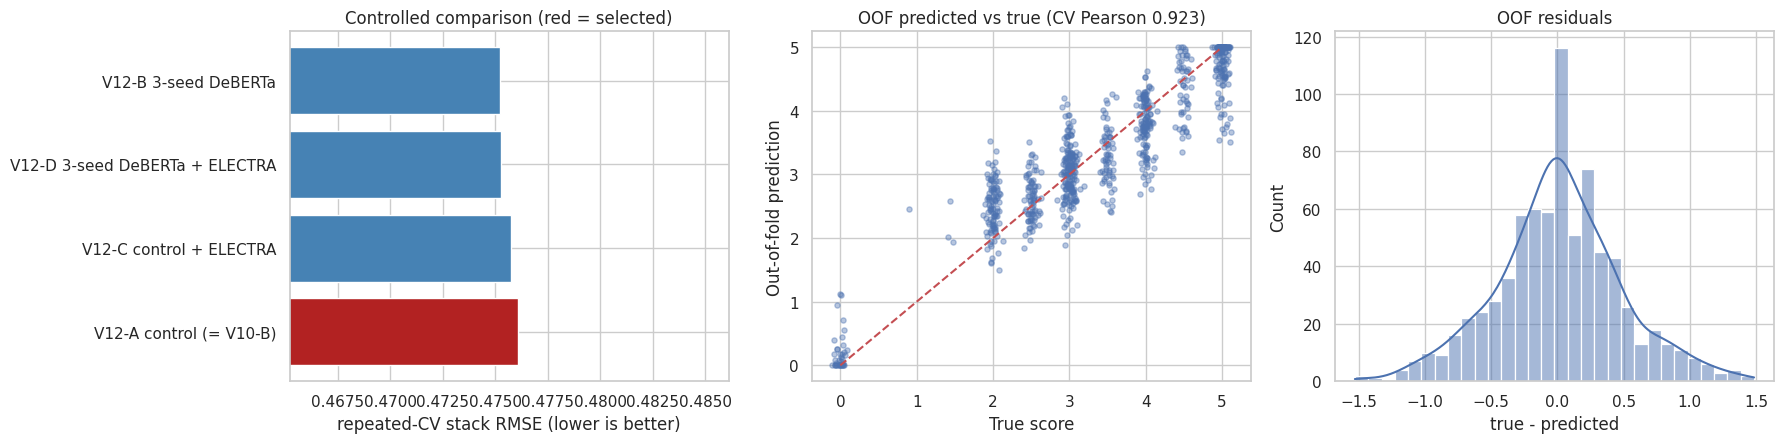

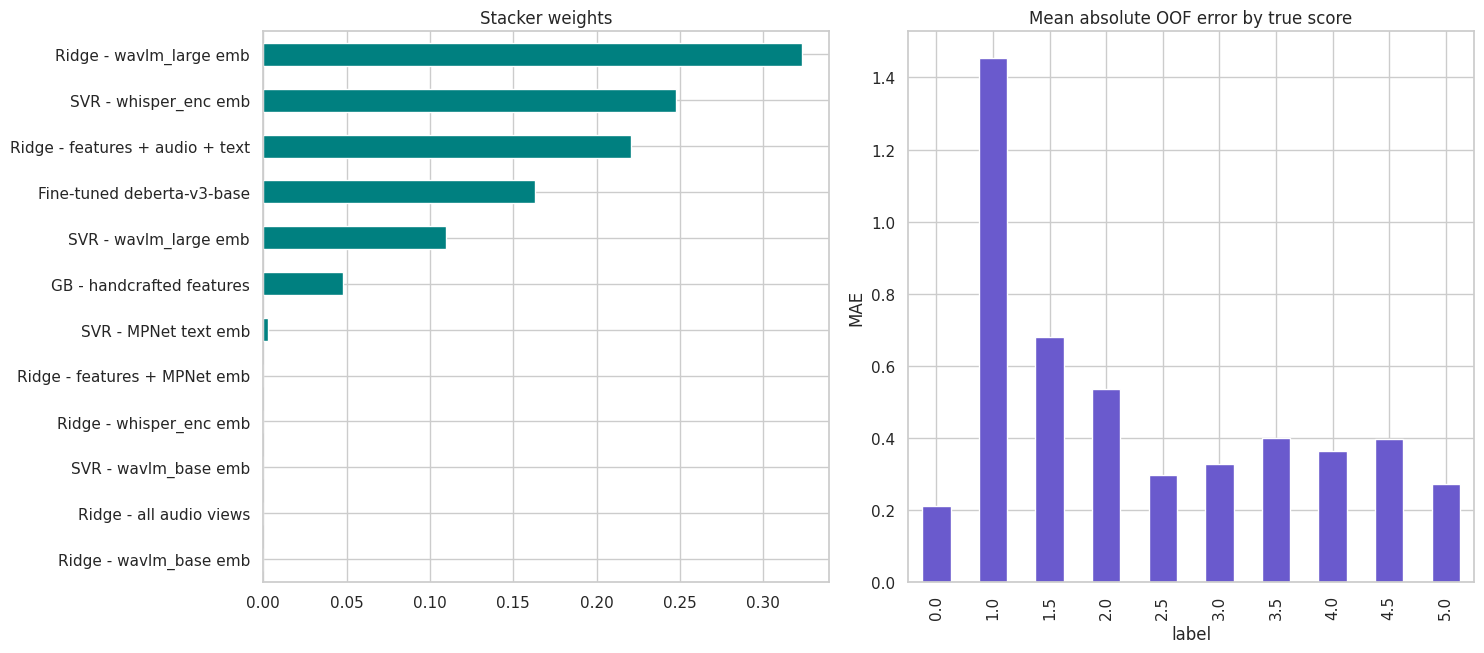

Largest out-of-fold errors:


,filename,true,pred,transcript,abs_err
162,audio_128.wav,2.0,3.53,Staying at a resort is a relaxing and enjoyabl...,1.53
226,audio_357.wav,5.0,3.51,There were slides and monkey bars and swing se...,1.49
423,audio_108.wav,1.0,2.46,As a young child one of the most exciting plac...,1.46
361,audio_555.wav,5.0,3.55,I'm gonna describe the scene of a crowded mark...,1.45
308,audio_321.wav,2.0,3.38,"Well, my favorite hobby, I can say my favorite...",1.38
724,audio_91.wav,5.0,3.65,Imagine a vibrant marketplace in vanilla bustl...,1.35
606,audio_159.wav,5.0,3.67,"Okay, I'm immersing in the melodic tranquility...",1.33
696,audio_107.wav,4.0,2.70,My goal in life is to become a hockey player b...,1.30


In [16]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4.6))
vs = variant_scores.sort_values("STACK CV RMSE", ascending=False)
ax[0].barh(vs["variant"], vs["STACK CV RMSE"], color=["firebrick" if v == selected else "steelblue" for v in vs["variant"]])
ax[0].set_xlim(vs["STACK CV RMSE"].min() - 0.01, vs["STACK CV RMSE"].max() + 0.01)
ax[0].set_xlabel("repeated-CV stack RMSE (lower is better)"); ax[0].set_title("Controlled comparison (red = selected)")
ax[1].scatter(y + np.random.normal(0, 0.05, n_tr), oof_stack, alpha=0.4, s=14); ax[1].plot([0, 5], [0, 5], "r--")
ax[1].set_xlabel("True score"); ax[1].set_ylabel("Out-of-fold prediction"); ax[1].set_title(f"OOF predicted vs true (CV Pearson {CV_PEARSON:.3f})")
res_ = y - oof_stack; sns.histplot(res_, bins=30, kde=True, ax=ax[2]); ax[2].set_title("OOF residuals"); ax[2].set_xlabel("true - predicted")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(15, 0.35 * len(names) + 2.5))
stack_weights.sort_values().plot.barh(ax=ax[0], color="teal"); ax[0].set_title("Stacker weights")
pd.DataFrame({"label": y, "err": np.abs(res_)}).groupby("label")["err"].mean().plot.bar(ax=ax[1], color="slateblue")
ax[1].set_title("Mean absolute OOF error by true score"); ax[1].set_ylabel("MAE")
plt.tight_layout(); plt.show()

bad = pd.DataFrame({"filename": all_df.loc[tr_mask, "filename"].values, "true": y, "pred": oof_stack.round(2),
                    "transcript": all_df.loc[tr_mask, "transcript"].str[:180].values})
bad["abs_err"] = (bad.true - bad.pred).abs()
print("Largest out-of-fold errors:"); display(bad.sort_values("abs_err", ascending=False).head(8))

## 10. Development history
| Version | Main change | CV RMSE | CV Pearson | Leaderboard |
|---|---|---|---|---|
| v1 | Whisper transcript → handcrafted features + MiniLM, GB + Ridge | 0.790 | 0.772 | 0.4977 |
| v2 | + WavLM audio embeddings, fine-tuned DeBERTa, stacking | 0.4954 | 0.9168 | 0.3738 |
| v4 | + Whisper-encoder / WavLM-large views, fixed Ridge weights, bootstrap CIs | 0.4779 | 0.9228 | 0.3694 |
| v5 | layer probe, Whisper-medium, repeated CV, isotonic calibration | 0.4751 (iso) / 0.4777 (linear) | 0.9235 / 0.9229 | 0.3780 (iso) / 0.3697 (linear) |
| v6 | frame-level features: segment pooling + temporal conv/attention heads | 0.4760 | 0.9234 | not submitted |
| v8 | V4 architecture, hyper-parameter tuning only | 0.4788 | 0.9225 | 0.3707 |
| v9 | 90 % v4 + 10 % frozen v8 predictions | n/a (not CV-validated) | n/a | 0.3693 |
| v10 | + focused grammar/syntax/disfluency features (V10-B); pruning variant (V10-C) 0.4770 rejected | 0.4761 | 0.9234 | 0.3670 (with 10 % v8 blend) |
| v11 | + construction / agreement / tense-consistency features — rejected by CV (0.4767 / 0.4773) | 0.4760 | 0.9235 | 0.3669 (with blend) |
| **v12** | blend removed; DeBERTa 3 seeds + ELECTRA tested with a pre-registered rule | *see results below* | | *to be submitted* |

**Lessons.** (1) Adding audio embeddings was the one large step (0.4977 → 0.3738). (2) Every later change moved the leaderboard by ≤ 0.003, within noise. (3) Isotonic calibration lowered CV RMSE slightly but hurt the leaderboard (0.3780 vs 0.3697 for the same models) — plateau-shaped calibrations are unsafe at the low end of the scale. (4) Blends of near-identical models (test-prediction correlation 0.998) cannot add information. *Leaderboard score = the competition's metric, on a different scale from plain CV RMSE.*

## 11. Report

In [17]:
vtbl = "\n".join(f"| {r['variant']} | {r['STACK CV RMSE']:.4f} | {r['STACK CV Pearson']:.4f} | {int(r['n_base_models'])} |" for _, r in variant_scores.iterrows())
mtbl = "\n".join(f"| {r['model']} | {r['group']} | {r['CV RMSE']:.4f} | {r['CV Pearson']:.4f} |" for _, r in model_table.iterrows())
atbl = "\n".join(f"| without {r['stack without group']} | {r['CV RMSE']:.4f} | {r['CV Pearson']:.4f} |" for _, r in abl.iterrows())
wtbl = "\n".join(f"| {n} | {v:.3f} |" for n, v in stack_weights.items())
views = ", ".join(f"{k} ({v.shape[1]} dims)" for k, v in AUDIO_VIEWS.items())
display(Markdown(f'''
### Pipeline
`audio → 16 kHz mono → (a) Whisper-small transcript → {FEATS_ENGINEERED.shape[1]} handcrafted features (text, repetition, audio, GPT-2 perplexity, LanguageTool, spaCy, grammar/syntax/disfluency), MPNet embeddings, fine-tuned transformer(s)  |  (b) audio views: {views} → {len(names)} base models (GB, Ridge, SVR, fine-tuned transformers) on 5-fold CV → non-negative linear stacker → clip to [0, 5]`

### Key results (selected variant: **{selected}**)
| Metric | Value |
|---|---|
| **Training RMSE (final ensemble, training clips)** | **{TRAIN_RMSE:.4f}** |
| Training Pearson | {TRAIN_PEARSON:.4f} |
| **CV RMSE (out-of-fold, repeated stack CV)** | **{CV_RMSE:.4f}** (95% bootstrap CI {CI_RMSE[0]:.3f}–{CI_RMSE[1]:.3f}) |
| **CV Pearson** | **{CV_PEARSON:.4f}** (95% bootstrap CI {CI_PEARSON[0]:.3f}–{CI_PEARSON[1]:.3f}) |
| Baseline RMSE (predict the mean) | {BASE_RMSE:.4f} |

*Training RMSE note:* base-model training predictions are averages of the five fold models (each saw 80% of the training clips) passed through the final stacker, so it is a mildly optimistic in-sample figure. The CV numbers are the honest estimate of generalisation.

### Controlled experiment and decision rule
| Stack variant | CV RMSE | CV Pearson | Base models |
|---|---|---|---|
{vtbl}

Rule (fixed before running): adopt a challenger only if RMSE improves by ≥ 0.002 over the control without losing Pearson. **Outcome:** {decision}.

### Per-model CV results (selected stack)
| Model | Group | CV RMSE | CV Pearson |
|---|---|---|---|
{mtbl}

### Ablation (what each model group contributes)
| Stack variant | CV RMSE | CV Pearson |
|---|---|---|
{atbl}

### Stacker weights
| Model | Weight |
|---|---|
{wtbl}

intercept = {final_stacker.intercept_:.3f}

### Design decisions
- **Out-of-fold stacking with shared folds**, stack evaluated by separately seeded CV; no test labels or test predictions enter any fitting or selection step.
- **Train and test share file names**, so audio paths and caches are keyed by *(split, filename)*; transcript-dependent caches carry a transcript fingerprint.
- **Audio carries most of the signal**, so three complementary audio encoders are used; the fine-tuned transformer provides the complementary text view.
- **No post-hoc calibration or external blends:** both were tested earlier and did not generalise (see section 10).
- **Pre-registered adoption rule** for the v12 experiment, because differences below ≈ 0.003 are within noise.

### Limitations and next steps
- Labels are subjective half-point MOS ratings, which sets a noise floor on RMSE; the bootstrap interval is about ±0.026 on CV RMSE.
- ASR normalises some speaker errors, so grammar mistakes can be lost before the text models see them.
- Predictions stay compressed at the extremes (scores 0–1 and 5).
- Further ideas: end-to-end fine-tuning of an audio encoder; temporal heads on frame-level features (they carried the largest stacker weight in v6 but were not tuned).
'''))


### Pipeline
`audio → 16 kHz mono → (a) Whisper-small transcript → 65 handcrafted features (text, repetition, audio, GPT-2 perplexity, LanguageTool, spaCy, grammar/syntax/disfluency), MPNet embeddings, fine-tuned transformer(s)  |  (b) audio views: wavlm_base (4608 dims), whisper_enc (4608 dims), wavlm_large (6144 dims) → 12 base models (GB, Ridge, SVR, fine-tuned transformers) on 5-fold CV → non-negative linear stacker → clip to [0, 5]`

### Key results (selected variant: **V12-A control (= V10-B)**)
| Metric | Value |
|---|---|
| **Training RMSE (final ensemble, training clips)** | **0.1894** |
| Training Pearson | 0.9883 |
| **CV RMSE (out-of-fold, repeated stack CV)** | **0.4761** (95% bootstrap CI 0.449–0.502) |
| **CV Pearson** | **0.9234** (95% bootstrap CI 0.910–0.935) |
| Baseline RMSE (predict the mean) | 1.2382 |

*Training RMSE note:* base-model training predictions are averages of the five fold models (each saw 80% of the training clips) passed through the final stacker, so it is a mildly optimistic in-sample figure. The CV numbers are the honest estimate of generalisation.

### Controlled experiment and decision rule
| Stack variant | CV RMSE | CV Pearson | Base models |
|---|---|---|---|
| V12-A control (= V10-B) | 0.4761 | 0.9234 | 12 |
| V12-B 3-seed DeBERTa | 0.4752 | 0.9238 | 12 |
| V12-C control + ELECTRA | 0.4757 | 0.9236 | 13 |
| V12-D 3-seed DeBERTa + ELECTRA | 0.4753 | 0.9237 | 13 |

Rule (fixed before running): adopt a challenger only if RMSE improves by ≥ 0.002 over the control without losing Pearson. **Outcome:** control kept: best challenger V12-B 3-seed DeBERTa reaches 0.4752 vs control 0.4761 (gain 0.0009 < 0.002).

### Per-model CV results (selected stack)
| Model | Group | CV RMSE | CV Pearson |
|---|---|---|---|
| Ridge - wavlm_large emb | audio_wavlm_large | 0.5114 | 0.9109 |
| Ridge - all audio views | audio_combined | 0.5156 | 0.9094 |
| Ridge - features + audio + text | multimodal | 0.5277 | 0.9049 |
| SVR - wavlm_large emb | audio_wavlm_large | 0.5295 | 0.9072 |
| Ridge - whisper_enc emb | audio_whisper_enc | 0.5446 | 0.8988 |
| Ridge - wavlm_base emb | audio_wavlm_base | 0.5469 | 0.8973 |
| SVR - whisper_enc emb | audio_whisper_enc | 0.5478 | 0.9019 |
| SVR - wavlm_base emb | audio_wavlm_base | 0.5511 | 0.8971 |
| Fine-tuned deberta-v3-base | finetune | 0.7798 | 0.7804 |
| GB - handcrafted features | features | 0.8240 | 0.7466 |
| Ridge - features + MPNet emb | text | 0.8717 | 0.7108 |
| SVR - MPNet text emb | text | 0.9848 | 0.6068 |

### Ablation (what each model group contributes)
| Stack variant | CV RMSE | CV Pearson |
|---|---|---|
| without audio_combined | 0.4761 | 0.9235 |
| without audio_wavlm_base | 0.4761 | 0.9234 |
| without audio_wavlm_large | 0.4838 | 0.9208 |
| without audio_whisper_enc | 0.4809 | 0.9217 |
| without features | 0.4765 | 0.9233 |
| without finetune | 0.4853 | 0.9204 |
| without multimodal | 0.4796 | 0.9223 |
| without text | 0.4749 | 0.9238 |

### Stacker weights
| Model | Weight |
|---|---|
| Ridge - wavlm_large emb | 0.323 |
| SVR - whisper_enc emb | 0.248 |
| Ridge - features + audio + text | 0.221 |
| Fine-tuned deberta-v3-base | 0.163 |
| SVR - wavlm_large emb | 0.110 |
| GB - handcrafted features | 0.048 |
| SVR - MPNet text emb | 0.003 |
| Ridge - wavlm_base emb | 0.000 |
| Ridge - whisper_enc emb | 0.000 |
| SVR - wavlm_base emb | 0.000 |
| Ridge - all audio views | 0.000 |
| Ridge - features + MPNet emb | 0.000 |

intercept = -0.382

### Design decisions
- **Out-of-fold stacking with shared folds**, stack evaluated by separately seeded CV; no test labels or test predictions enter any fitting or selection step.
- **Train and test share file names**, so audio paths and caches are keyed by *(split, filename)*; transcript-dependent caches carry a transcript fingerprint.
- **Audio carries most of the signal**, so three complementary audio encoders are used; the fine-tuned transformer provides the complementary text view.
- **No post-hoc calibration or external blends:** both were tested earlier and did not generalise (see section 10).
- **Pre-registered adoption rule** for the v12 experiment, because differences below ≈ 0.003 are within noise.

### Limitations and next steps
- Labels are subjective half-point MOS ratings, which sets a noise floor on RMSE; the bootstrap interval is about ±0.026 on CV RMSE.
- ASR normalises some speaker errors, so grammar mistakes can be lost before the text models see them.
- Predictions stay compressed at the extremes (scores 0–1 and 5).
- Further ideas: end-to-end fine-tuning of an audio encoder; temporal heads on frame-level features (they carried the largest stacker weight in v6 but were not tuned).
